# C5 Grid Search — UA-ASL Hyperparameter Tuning
**γ⁺ ∈ {0,1,2} × γ⁻ ∈ {2,3,4} × λu ∈ {0.3,0.5,0.7} → 27 runs**  
Metric chọn best: `unc_AUC` trên `val_uncertain`  
Mỗi run: 5 epoch × 20% stratified train data

In [6]:
import os, sys

WORK  = '/kaggle/working'
REPO  = 'https://github.com/PhuongThao-2005/TULIP-MedML.git'
RNAME = 'TULIP-MedML'
BRANCH = 'grid-search'

if os.path.exists(f'{WORK}/{RNAME}'):
    os.system(f'cd {WORK}/{RNAME} && git fetch origin')
    os.system(f'cd {WORK}/{RNAME} && git checkout {BRANCH}')
    os.system(f'cd {WORK}/{RNAME} && git pull origin {BRANCH}')
    print(f'Pulled latest ({BRANCH})')
else:
    os.system(f'cd {WORK} && git clone -b {BRANCH} {REPO}')
    print(f'Cloned ({BRANCH})')

os.system('pip install pyyaml timm -q')
sys.path.insert(0, f'{WORK}/{RNAME}')
os.chdir(f'{WORK}/{RNAME}')

print('Working dir :', os.getcwd())
print('Repo contents:', os.listdir('.'))

Already on 'grid-search'


Your branch is up to date with 'origin/grid-search'.


From https://github.com/PhuongThao-2005/TULIP-MedML
 * branch            grid-search -> FETCH_HEAD


Already up to date.
Pulled latest (grid-search)
Working dir : /kaggle/working/TULIP-MedML
Repo contents: ['tests', 'data', 'notebooks', '.gitignore', 'src', 'requirements.txt', 'README.md', '.git']


In [7]:
# ── 0. Paths — chỉ cần chỉnh block này ──────────────────────────────────────
import sys, os

PROJECT_ROOT = "/kaggle/working/TULIP-MedML"   # root của project
CONFIG_PATH  = f"{PROJECT_ROOT}/src/configs/c5_tulip.yaml"
DATA_ROOT    = "/kaggle/input/datasets/ashery/chexpert"  # optional override

sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print("Working dir:", os.getcwd())

Working dir: /kaggle/working/TULIP-MedML


In [8]:
# import shutil
# import os

# SRC = "/kaggle/input/notebooks/phuongthao205/c5-grid-search/logs/c5/grid_results.json"
# DST = "/kaggle/working/logs/c5/grid_results.json"

# if os.path.exists(SRC):
#     shutil.copytree(SRC, DST, dirs_exist_ok=True)
#     print(" Copied checkpoints to working")
# else:
#     print("None")

In [9]:
# ── 2. Run grid search (THỰC) ────────────────────────────────────────────────
# Ước tính ~2–3h trên Kaggle T4 với 5 epoch × 20% data × 27 runs
# Kết quả tự save vào cfg['output']['log_dir']

from src.grid_search_c5 import run_grid_search

results, best = run_grid_search(
    config_path=CONFIG_PATH,
    data_root=DATA_ROOT,
    n_epochs=5,          # 5 epoch đủ để rank, không cần converge
)

Device        : cuda
Grid size     : 27  runs  (γ+=[0, 1, 2] × γ-=[2, 3, 4] × λu=[0.3, 0.5, 0.7])
Epochs / run  : 5
[CheXpert] 2234 samples | policy=keep
[CheXpert] 500 samples | policy=keep
Train (v3)    : 2,234 samples  <- read as-is from train_csv
Val uncertain : 500 samples

Resuming — 11 runs already done: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
[01/27] SKIP (already done)
[02/27] SKIP (already done)
[03/27] SKIP (already done)
[04/27] SKIP (already done)
[05/27] SKIP (already done)
[06/27] SKIP (already done)
[07/27] SKIP (already done)
[08/27] SKIP (already done)
[09/27] SKIP (already done)
[10/27] SKIP (already done)
[11/27] SKIP (already done)

───────────────────────────────────────────────────────
[12/27]  γ+=1  γ-=2  λu=0.7
───────────────────────────────────────────────────────
  epoch 01/5  loss=0.1451
  epoch 02/5  loss=0.1370
  epoch 03/5  loss=0.1322
  epoch 04/5  loss=0.1280
  epoch 05/5  loss=0.1246
  → mAP=0.2325  AUC=0.5339  unc_AUC=0.5156  (2.6 min)
  [checkpoint] sav

In [10]:
# ── 2. Run grid search (THỰC) ────────────────────────────────────────────────
# Ước tính ~2–3h trên Kaggle T4 với 5 epoch × 20% data × 27 runs
# Kết quả tự save vào cfg['output']['log_dir']

from src.grid_search_c5 import run_grid_search

results, best = run_grid_search(
    config_path=CONFIG_PATH,
    data_root=DATA_ROOT,
    n_epochs=5,          # 5 epoch đủ để rank, không cần converge
)

Device        : cuda
Grid size     : 27  runs  (γ+=[0, 1, 2] × γ-=[2, 3, 4] × λu=[0.3, 0.5, 0.7])
Epochs / run  : 5
[CheXpert] 2234 samples | policy=keep
[CheXpert] 500 samples | policy=keep
Train (v3)    : 2,234 samples  <- read as-is from train_csv
Val uncertain : 500 samples

Resuming — 27 runs already done: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
[01/27] SKIP (already done)
[02/27] SKIP (already done)
[03/27] SKIP (already done)
[04/27] SKIP (already done)
[05/27] SKIP (already done)
[06/27] SKIP (already done)
[07/27] SKIP (already done)
[08/27] SKIP (already done)
[09/27] SKIP (already done)
[10/27] SKIP (already done)
[11/27] SKIP (already done)
[12/27] SKIP (already done)
[13/27] SKIP (already done)
[14/27] SKIP (already done)
[15/27] SKIP (already done)
[16/27] SKIP (already done)
[17/27] SKIP (already done)
[18/27] SKIP (already done)
[19/27] SKIP (already done)
[20/27] SKIP (already done)
[21/27] SKIP (already done)

In [11]:
# ── 3. Load kết quả đã lưu (nếu resume từ session khác) ─────────────────────
import json, yaml

with open(CONFIG_PATH) as f:
    _cfg = yaml.safe_load(f)
LOG_DIR = _cfg["output"]["log_dir"]

with open(f"{LOG_DIR}/grid_results.json") as f:
    results = json.load(f)

with open(f"{LOG_DIR}/best_params.json") as f:
    best = json.load(f)

print(f"Loaded {len(results)} runs.  Best unc_AUC = {best['unc_auc']:.4f}")
print(f"  γ+={best['gamma_pos']}  γ-={best['gamma_neg']}  λu={best['lambda_unc']}")

Loaded 27 runs.  Best unc_AUC = 0.5320
  γ+=2  γ-=2  λu=0.3



══════════════════════════════════════════════════
  Heatmap: unc_auc
══════════════════════════════════════════════════


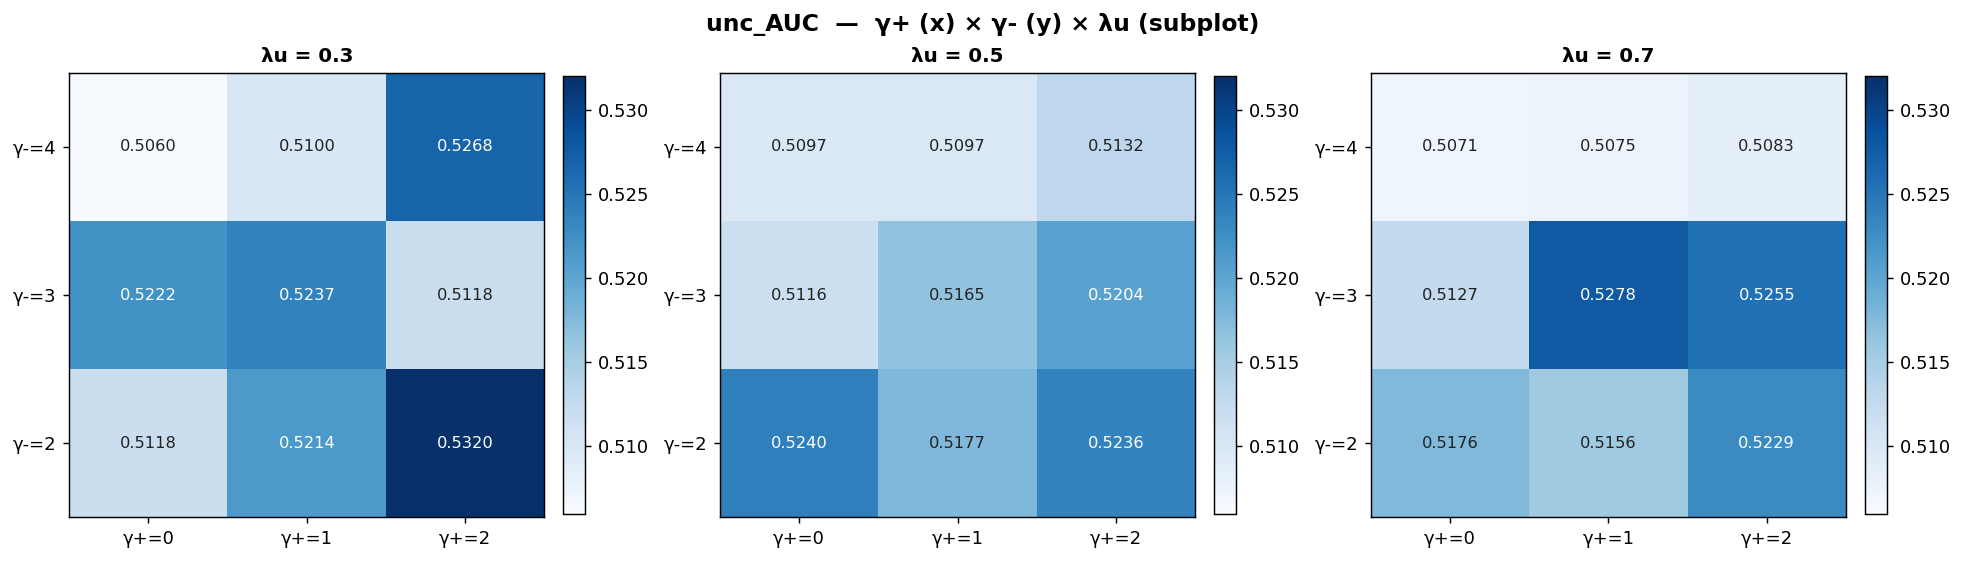


══════════════════════════════════════════════════
  Heatmap: mAP
══════════════════════════════════════════════════


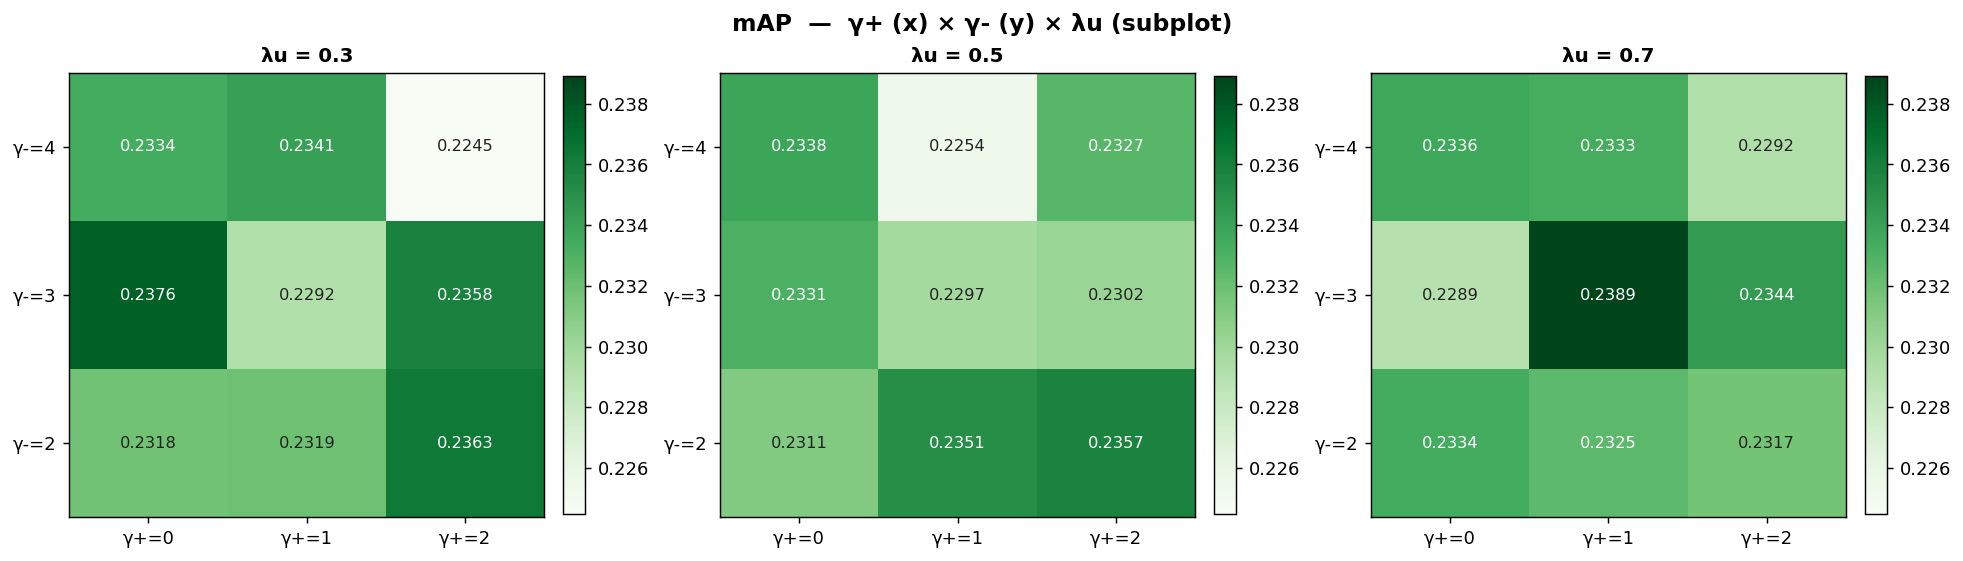


══════════════════════════════════════════════════
  Heatmap: mean_auc
══════════════════════════════════════════════════


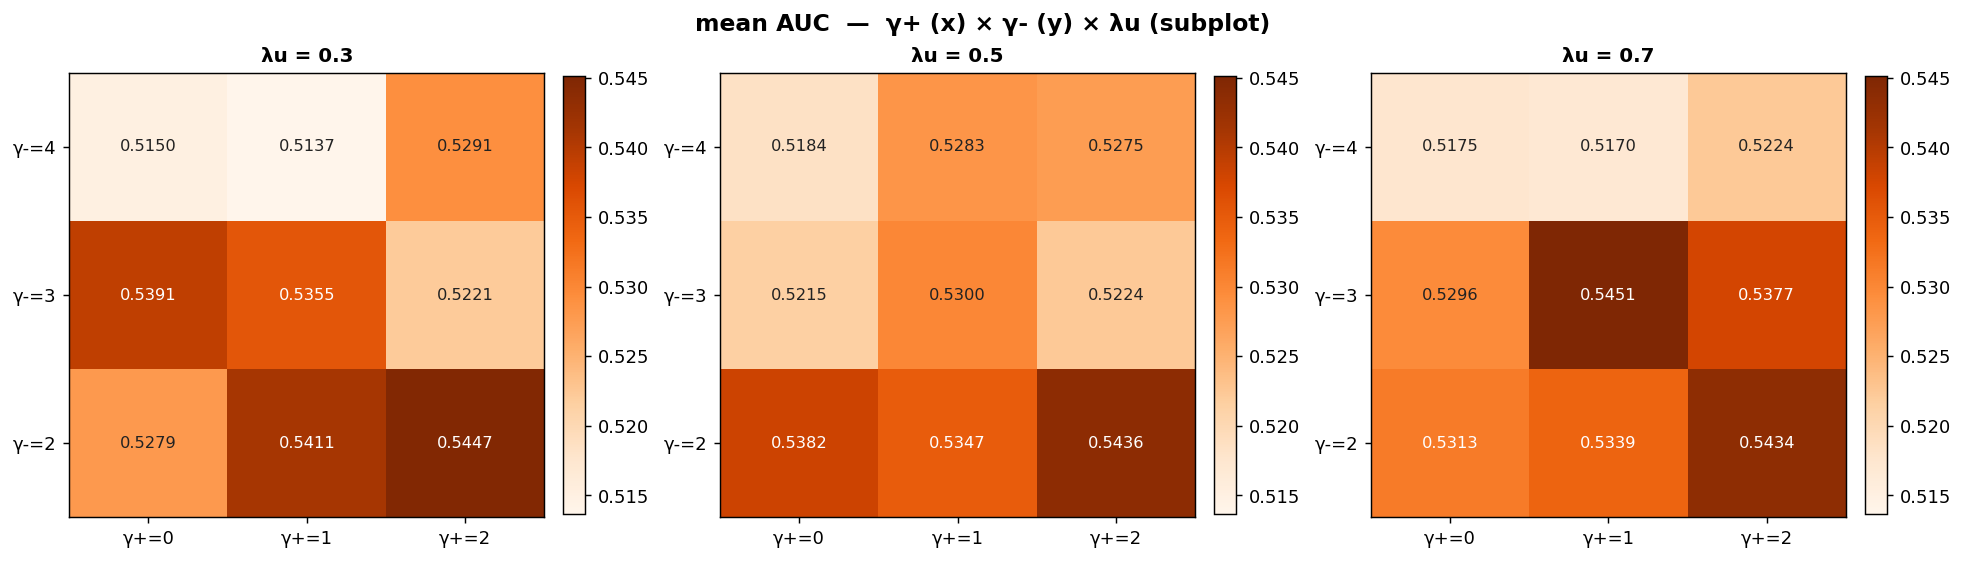

In [12]:
# ── 4a. Inline display — heatmaps (unc_AUC, mAP, mean_AUC) ──────────────────
from IPython.display import Image, display
import os

for metric in ["unc_auc", "mAP", "mean_auc"]:
    path = os.path.join(LOG_DIR, f"grid_heatmap_{metric}.png")
    if os.path.isfile(path):
        print(f"\n{'═'*50}")
        print(f"  Heatmap: {metric}")
        print(f"{'═'*50}")
        display(Image(filename=path, width=900))
    else:
        print(f"[missing] {path}")

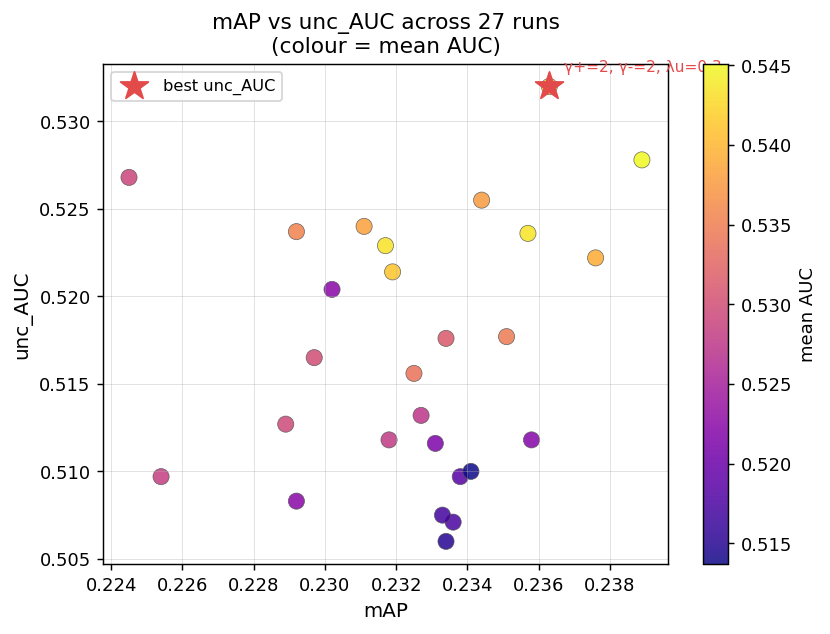

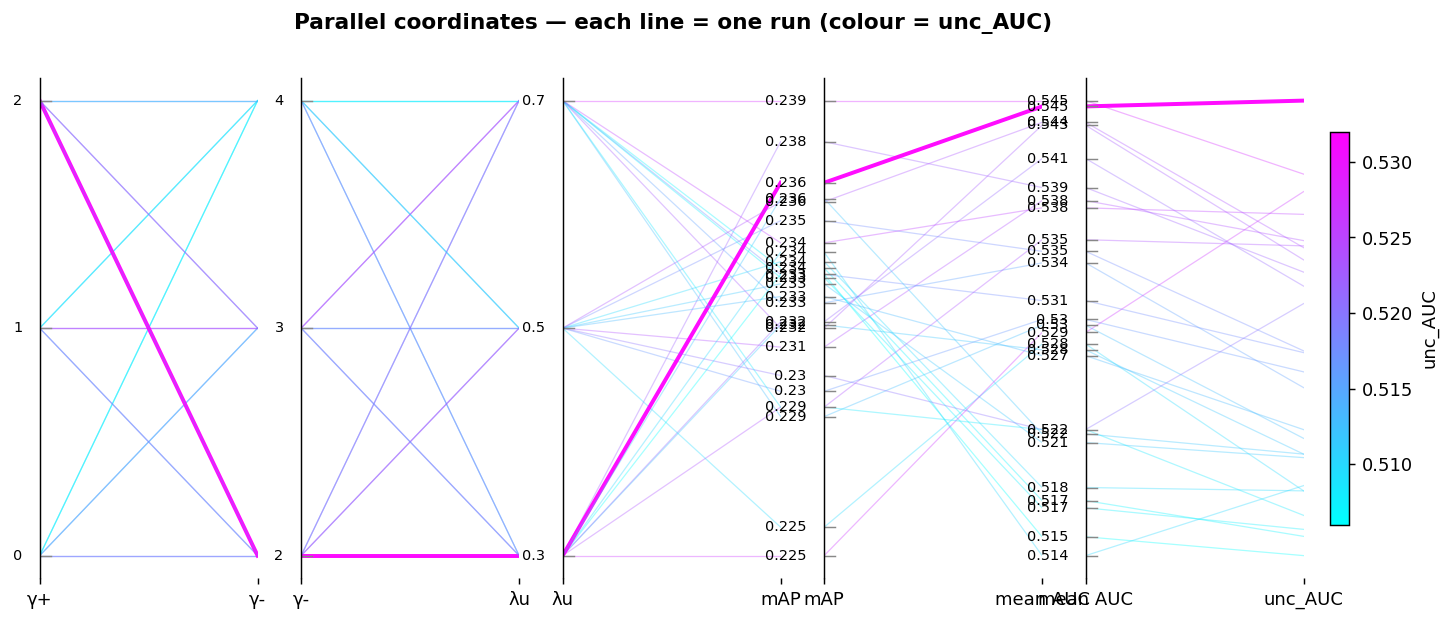

In [13]:
# ── 4b. Inline display — scatter + parallel coordinates ─────────────────────
from IPython.display import Image, display

for fname in ["grid_scatter.png", "grid_parallel.png"]:
    path = os.path.join(LOG_DIR, fname)
    if os.path.isfile(path):
        display(Image(filename=path, width=900))
    else:
        print(f"[missing] {path}")

In [14]:
# ── 5. Pandas summary table — tất cả 27 runs ────────────────────────────────
import pandas as pd

df = pd.DataFrame(results)[
    ["run_id", "gamma_pos", "gamma_neg", "lambda_unc",
     "mAP", "mean_auc", "unc_auc", "elapsed_min"]
].sort_values("unc_auc", ascending=False).reset_index(drop=True)

# Highlight best row
def _highlight_best(row):
    is_best = (
        row["gamma_pos"]  == best["gamma_pos"] and
        row["gamma_neg"]  == best["gamma_neg"] and
        row["lambda_unc"] == best["lambda_unc"]
    )
    return ["background-color: #d4edda" if is_best else "" for _ in row]

df.style\
    .apply(_highlight_best, axis=1)\
    .format({"mAP": "{:.4f}", "mean_auc": "{:.4f}",
             "unc_auc": "{:.4f}", "elapsed_min": "{:.1f}"})\
    .background_gradient(subset=["unc_auc"], cmap="Blues")\
    .background_gradient(subset=["mAP"], cmap="Greens")\
    .background_gradient(subset=["mean_auc"], cmap="Oranges")\
    .set_caption("Grid search results — sorted by unc_AUC (best highlighted)")

,run_id,gamma_pos,gamma_neg,lambda_unc,mAP,mean_auc,unc_auc,elapsed_min
0,19,2,2,0.300000,0.2363,0.5447,0.5320,2.6
1,15,1,3,0.700000,0.2389,0.5451,0.5278,2.6
2,25,2,4,0.300000,0.2245,0.5291,0.5268,2.6
3,24,2,3,0.700000,0.2344,0.5377,0.5255,2.7
4,2,0,2,0.500000,0.2311,0.5382,0.5240,2.6
5,13,1,3,0.300000,0.2292,0.5355,0.5237,2.7
6,20,2,2,0.500000,0.2357,0.5436,0.5236,2.6
7,21,2,2,0.700000,0.2317,0.5434,0.5229,2.6
8,4,0,3,0.300000,0.2376,0.5391,0.5222,2.6
9,10,1,2,0.300000,0.2319,0.5411,0.5214,2.6


In [16]:
# ── 6. Re-generate plots bất cứ lúc nào (sau khi đã có results) ─────────────
from src.grid_search_c5 import _make_visualisations

_make_visualisations(results, LOG_DIR)
print("Plots regenerated →", LOG_DIR)

  Saved /kaggle/working/logs/c5/grid_heatmap_unc_auc.png
  Saved /kaggle/working/logs/c5/grid_heatmap_mAP.png
  Saved /kaggle/working/logs/c5/grid_heatmap_mean_auc.png
  Saved /kaggle/working/logs/c5/grid_scatter.png
  Saved /kaggle/working/logs/c5/grid_parallel.png
Plots regenerated → /kaggle/working/logs/c5


In [17]:
# ── 7. In best params — paste vào config để train full ──────────────────────
print("Best hyperparameters (paste into c5_tulip.yaml):")
print()
print("loss:")
print(f"  type:       ua_asl")
print(f"  gamma_pos:  {best['gamma_pos']}")
print(f"  gamma_neg:  {best['gamma_neg']}")
print(f"  lambda_unc: {best['lambda_unc']}")
print()
print(f"Best unc_AUC  = {best['unc_auc']:.4f}")
print(f"Best mAP      = {best['mAP']:.4f}")
print(f"Best mean_AUC = {best['mean_auc']:.4f}")

Best hyperparameters (paste into c5_tulip.yaml):

loss:
  type:       ua_asl
  gamma_pos:  2
  gamma_neg:  2
  lambda_unc: 0.3

Best unc_AUC  = 0.5320
Best mAP      = 0.2363
Best mean_AUC = 0.5447
